In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

# Train one agent for a single environment

In [3]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

In [90]:
env_param = [0, 800, 0.087213, .25, -30, 0, 0]

# change back to old no. of epochs
num_epochs = 20

agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = 3)

Checkpoint (epoch 720) loaded.


Fetching the most trained agent so far (epoch 721).
Agent (seed 0) was trained for 721 epochs, RL optimality 100.00%.


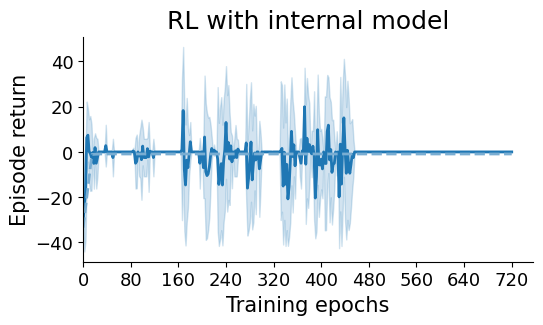

In [89]:
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

In [5]:
# weights_bias_dict = manager.agent_trained_wegihts_biases(env_param)
# from auditoryforage.utils import save_pickle_file

# print(f"biases are {weights_bias_dict['action_net_bias']}")
# print(f"weights are {weights_bias_dict['action_net_weight']}")
# label_font_size = 16



# for action_choice in range(len(weights_bias_dict['action_net_bias'])):
#     plt.figure()

#     # plt.stem(weights_bias_dict['action_net_weight'][action_choice][:-2])


#     signal_list = [elt  if ind!=0 else None for ind, elt in enumerate(weights_bias_dict['action_net_weight'][action_choice][:-2])]
#     noise_list = [elt  if ind==0 else None for ind, elt in enumerate(weights_bias_dict['action_net_weight'][action_choice][:-2])]
    
#     markerline, stemlines, baseline = plt.stem(signal_list, markerfmt = 'og')
#     plt.setp(baseline, linewidth = .5, color='black')
#     plt.setp(stemlines, linewidth = .2, color='g')
#     plt.setp(markerline, markersize='8')

#     markerline, stemlines, baseline = plt.stem(noise_list, markerfmt = 'or')
#     plt.setp(baseline, linewidth = .5, color='black')
#     plt.setp(stemlines, linewidth = .2, color='r')
#     plt.setp(markerline, markersize='8')
    
#     # plt.title(f'weights for actions {action_choice}')
#     plt.ylabel('weight', fontsize = label_font_size)
#     plt.xlabel('node index', fontsize = label_font_size)
#     plt.savefig(f'../slides_data/action_{action_choice}.png', bbox_inches='tight', pad_inches=0, dpi=300)
#     plt.show()

# plt.figure()
# plt.title(f'bias for actions excluding last one')
# plt.stem(weights_bias_dict['action_net_bias'])
# plt.xlabel('action index')
# plt.show()

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

problem somwhere here
[[3]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [2]]
(array([48]), array([0]))
problem somwhere here
[[3]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [2]]
(array([48]), array([0]))
average success streak is 1.0
average success rate is 0.02512658830673778
average episode time is 44.431372549019606


{'agent': {'lick_cost': 0,
  'food_reward': 800,
  'attention_cost_coeff': 0.087213,
  'attention_cost_temp': 0.25,
  'penalty_cost': -30,
  'iti_cost': 0,
  'time_in_game_reward': 0,
  'no_attention_modes': 2},
 'experiment': {'prob_01': 0.024,
  'no_signal_nodes': 25,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1}}

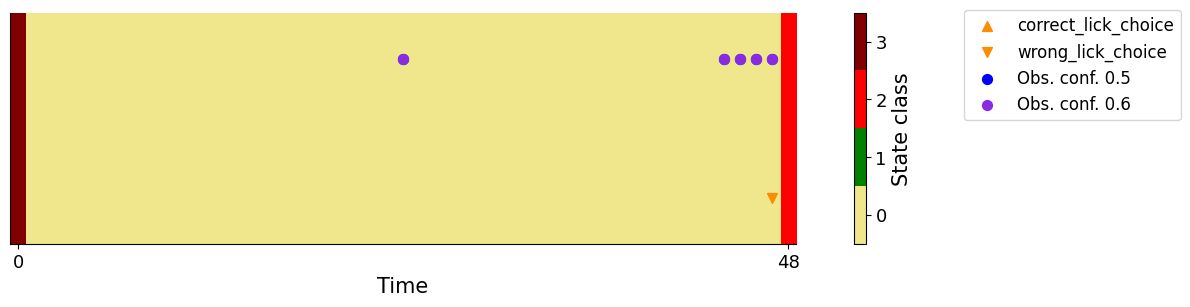

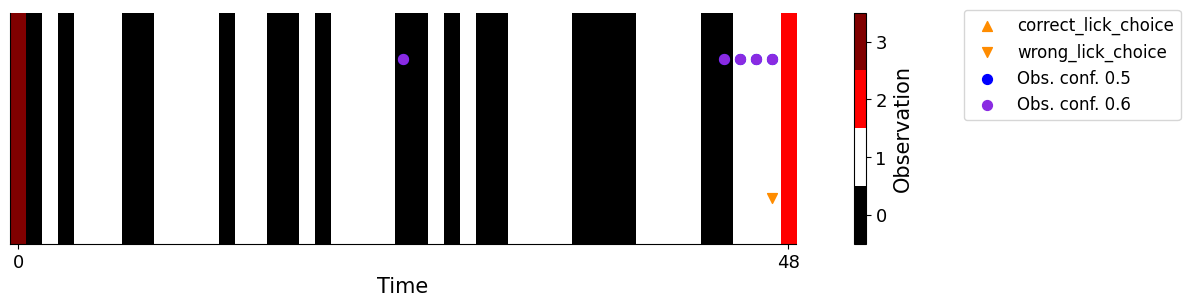

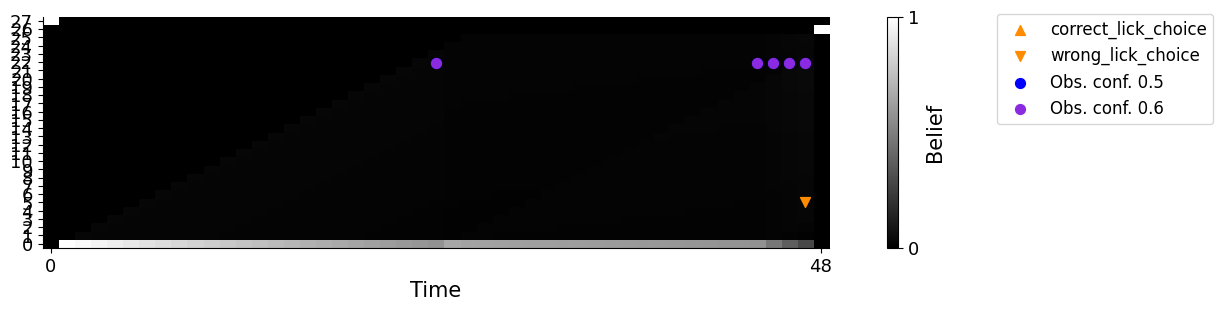

In [91]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

env.spec

In [58]:
import torch

def find_activation(agent, belief):

    # check whether gradient should be stopped while doing these
    
    features = torch.tensor(belief, dtype=torch.float32)

    with torch.no_grad():
        policy_net_0_results = agent.algo.policy.mlp_extractor.policy_net[0](features)
        policy_net_1_results = agent.algo.policy.mlp_extractor.policy_net[1](policy_net_0_results)
        policy_net_2_results = agent.algo.policy.mlp_extractor.policy_net[2](policy_net_1_results)
        policy_net_3_results = agent.algo.policy.mlp_extractor.policy_net[3](policy_net_2_results)
        policy_net_4_results = agent.algo.policy.mlp_extractor.policy_net[4](policy_net_3_results)
    
    # policy_net_4_results = agent.algo.policy.action_net(policy_net_3_results)

    return policy_net_4_results

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())

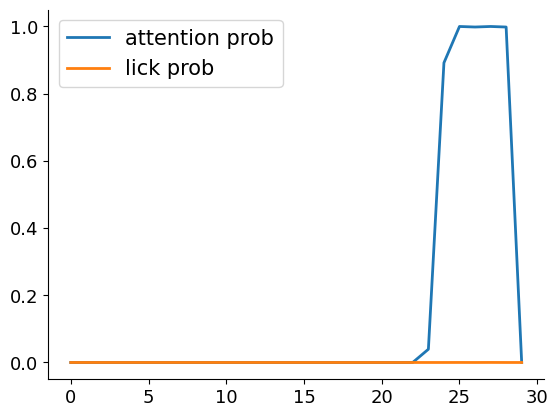

In [59]:
# plt.plot([activations_list[ind][0] for ind in range(len(activations_list)) ], label = 'opp. of time urgency')
# plt.plot([-activations_list[ind][1] for ind in range(len(activations_list)) ], label = 'attention urgency')
# plt.plot([-activations_list[ind][2] for ind in range(len(activations_list)) ], label = 'lick urgency')
# plt.legend()
# plt.show()


# lick_feature = [activations_list[:][1] - activations_list[ind][0]  for ind in range(len(activations_list))]
# attention_feature = [activations_list[ind][2] - activations_list[ind][0] for ind in range(len(activations_list))]
# plt.figure()
# plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
# plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
# plt.legend()
# plt.show()


lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature], label = 'lick prob')
plt.legend()
plt.show()

In [60]:
episode['beliefs'][-1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [151]:
len(episode['states'])

25

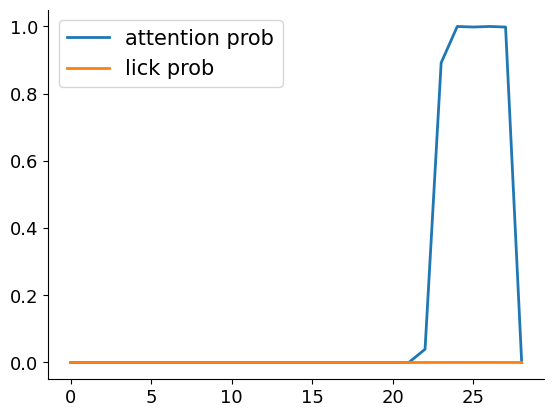

In [61]:
plt.figure()
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in attention_feature][1:], label = 'attention prob')
plt.plot([(1/(1+np.exp(-2 * elt))) for elt in lick_feature][1:], label = 'lick prob')
plt.legend()
plt.show()

In [54]:
plt.plot([policy_net_6_results_list[ind][0] for ind in range(len(policy_net_6_results_list)) ][1:], label = 'opp. of time urgency')

NameError: name 'policy_net_6_results_list' is not defined

In [ ]:
def count_no_elements(np_array, min_allowed, max_allowed):
    return len([elt for elt in list(np_array.flatten()) if elt >= min_allowed and elt <= max_allowed])

episode['states'].flatten()
print(list(episode['states'].flatten()).count(0))
print(count_no_elements(episode['states'], 0, 0))

noise_time_before_lick = count_no_elements(episode['states'], 0, 0)
signal_time_before_lick = count_no_elements(episode['states'], 1, env.no_signal_nodes)
total_noise_time = count_no_elements(episode['states'], 0, 0)
total_signal_time = count_no_elements(episode['states'], 1, env.no_signal_nodes)

In [ ]:
# from auditoryforage.utils import save_pickle_file
# file_name = './auditoryforage/filters/ref_episode_13_5.pkl'
# save_pickle_file(episode, file_name)

### Jump start

In [ ]:
from auditoryforage.utils import open_pickle_file, save_pickle_file
file_name = './auditoryforage/filters/ref_episode_0.08_0.25.pkl'
# save_pickle_file(episode, file_name)
episode = open_pickle_file(file_name)

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from irc.manager import IRCManager
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)
from auditoryforage.AF_env import AuditoryForaging
env_param = [-3.0, 200.0, .08, .25, -5000, 0]
env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})

# Load multiple agents

In [ ]:
env_param_list = []
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

env_param_list.append([-3.0, 200.0, 13, 5, -5000, 0])
env_param_list.append([-3.0, 200.0, .06, .25, -5000, 0])
env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

num_epochs = 400
num_epochs_list = [num_epochs] * len(env_param_list)

agent_list = []
for ind in range(len(env_param_list)):
    agent_list.append(manager.train_agent(env_param_list[ind], num_epochs=num_epochs_list[ind]))

# Particle filter

## Running Particle filter

### Latent  variable - only attention

In [ ]:
from auditoryforage.filters.PF_attention import ParticleFilter
end_index = 2
no_particles_list = [10000]
sampling_freq_list = [1]
particle_filter = ParticleFilter(agent, env)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - attention, and observation

In [ ]:
from auditoryforage.filters.PF_att_obs import ParticleFilter
end_index = 2
no_particles_list = [10000]
sampling_freq_list = [1]
particle_filter = ParticleFilter(agent, env)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - attention, and agents

In [ ]:
from auditoryforage.filters.PF_att_agent import ParticleFilter
end_index = 2
no_particles_list = [1000]
sampling_freq_list = [1]
true_params_folder_name = ''
particle_filter = ParticleFilter(agent_list, env_param_list, env, true_params_folder_name)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

### Latent  variable - agents

In [ ]:
from auditoryforage.filters.PF_agent import ParticleFilter
end_index = 2
no_particles_list = [1000]
sampling_freq_list = [1]
true_params_folder_name = ''
particle_filter = ParticleFilter(agent_list, env_param_list, env, true_params_folder_name)
particle_filter.multiple_filtering(episode, no_particles_list, sampling_freq_list, end_index, req_output_posterior = True)

## Particle filter generated episode

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_35.pkl'

from auditoryforage.filters.PF_attention import ParticleFilter
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
particle_filter = ParticleFilter(agent, env)
particle_filter.plot_generated_episode(file_name = PF_file_name, likelihood_rank = likelihood_rank)

## Analyzing particle filter output.

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_35.pkl'

from auditoryforage.filters.PF_attention import PF_results_analyzer
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - attention, and observation

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'

from auditoryforage.filters.PF_att_obs import PF_results_analyzer
PF_folder = 'store/filters/PF_att_obs/'
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - attention, and agents

In [ ]:
# PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
PF_file = 'PF_np_100_sf_1_ei_1000_rn_63.pkl'
true_params_folder_name = ''

from auditoryforage.filters.PF_att_agent import PF_results_analyzer
PF_folder = 'store/filters/PF_att_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

### Latent  variable - agents

In [ ]:
# env_param_list.append([-3.0, 200.0, 13, 5, -5000, 0])
# env_param_list.append([-3.0, 200.0, .06, .25, -5000, 0])
# env_param_list.append([-3.0, 200.0, .08, .25, -5000, 0])

# true_params_folder_name = '0-13_5/'
# PF_file = 'PF_np_30000_sf_1_ei_3080_rn_97.pkl'

# true_params_folder_name = '1-0.06_0.25/'
# PF_file = 'PF_np_30000_sf_1_ei_846_rn_66.pkl'

true_params_folder_name = '2-0.08_0.25/'
# PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
# PF_file = 'PF_np_100_sf_1_ei_1000_rn_63.pkl'
# PF_file = 'PF_np_1000_sf_1_ei_1000_rn_82.pkl'
# PF_file = 'PF_np_10000_sf_1_ei_1000_rn_92.pkl'
PF_file = 'PF_np_30000_sf_1_ei_2000_rn_39.pkl'

from auditoryforage.filters.PF_agent import PF_results_analyzer
PF_folder = 'store/filters/PF_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
likelihood_rank = 0
PF_results_analyzer(PF_file_name, likelihood_rank).analyze_results()

## Running HMM.

### Latent  variable - only attention

In [ ]:
from auditoryforage.filters.HMM_attention import HMM
end_index = 2
HMM_IO = HMM(agent, env, episode, end_index).compute_posterior_across_attention_series()

### Latent  variable - attention, and observation

In [ ]:
from auditoryforage.filters.HMM_att_obs import HMM
end_index = 2
HMM_IO = HMM(agent, env, episode, end_index).compute_posterior_across_attention_obs_series()

## Comparing particle filter and HMM outputs.

### Latent  variable - only attention

In [ ]:
PF_file = 'PF_np_100000_sf_1_ei_5_rn_66.pkl'
HMM_file = 'HMM_ei_5_rn_44.pkl'

from auditoryforage.filters.HMM_attention import compare_PF_HMM
PF_folder = 'store/filters/PF_attention/'
HMM_folder = 'store/filters/HMM_attention/'
PF_file_name = PF_folder + PF_file
HMM_file_name = HMM_folder + HMM_file
compare_PF_HMM(PF_file_name = PF_file_name, HMM_file_name = HMM_file_name)

### Latent  variable - attention, and observation

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'
HMM_file = 'HMM_ei_2_rn_98.pkl'

from auditoryforage.filters.HMM_att_obs import compare_PF_HMM
PF_folder = 'store/filters/PF_att_obs/'
HMM_folder = 'store/filters/HMM_att_obs/'
PF_file_name = PF_folder + PF_file
HMM_file_name = HMM_folder + HMM_file
compare_PF_HMM(PF_file_name = PF_file_name, HMM_file_name = HMM_file_name)

## Verifying if saved files makes sense

In [ ]:
from auditoryforage.utils import open_pickle_file, save_pickle_file

### Latent  variable - only attention

#### PF

In [ ]:
PF_file = 'PF_np_100000_sf_1_ei_5_rn_66.pkl'
PF_folder = 'store/filters/PF_attention/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

#### HMM

In [ ]:
HMM_file = 'HMM_ei_5_rn_44.pkl'
HMM_folder = 'store/filters/HMM_attention/'
HMM_file_name = HMM_folder + HMM_file
HMM_IO = open_pickle_file(PF_file_name)

### Latent  variable - attention, and observation

#### PF

In [ ]:
PF_file = 'PF_np_10000_sf_1_ei_2_rn_8.pkl'
PF_folder = 'store/filters/PF_att_obs/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

#### HMM

In [ ]:
HMM_file = 'HMM_ei_2_rn_98.pkl'
HMM_folder = 'store/filters/HMM_att_obs/'
HMM_file_name = HMM_folder + HMM_file
HMM_IO = open_pickle_file(PF_file_name)

### Latent  variable - attention, and agents

#### PF

In [ ]:
PF_file = 'PF_np_30000_sf_1_ei_100_rn_24.pkl'
PF_folder = 'store/filters/PF_att_agent/'
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)

In [ ]:
PF_IO['output']['sorted_results']['agent']['agent_ranked']

### Latent  variable - agents

In [ ]:
# PF_file = 'PF_np_30000_sf_1_ei_2205_rn_36.pkl'
# true_params_folder_name = '/high_en_2_tn_0_fr_350_ac_0.08_0.25/'

# PF_file = 'PF_np_30000_sf_1_ei_5315_rn_97.pkl'
# true_params_folder_name = '/low_en_2_tn_2_fr_50_ac_0.08_0.25/'

# PF_file = 'PF_np_30000_sf_1_ei_2205_rn_36.pkl'
# true_params_folder_name = '/high_en_2_tn_0_fr_100_ac_0.08_0.25/'

PF_folder = 'store/filters/PF_agent/' + true_params_folder_name
PF_file_name = PF_folder + PF_file
PF_IO = open_pickle_file(PF_file_name)
print(PF_IO['output']['sorted_results']['agent'])


## Summary results for a mice

In [ ]:
import os
results = []
main_dir = './store/filters/PF_agent/high_fr_350.0_ac_0.08_0.25'
for folder_name in os.listdir(main_dir):
    for file_name in os.listdir(main_dir + '/' + folder_name):
        results.append(open_pickle_file(main_dir + '/' + folder_name + '/' + file_name)['output']['sorted_results']['agent'])

## Deciding good att cost temp

In [ ]:
y = x1 * (np.exp(a/x2) - 1)
x2 = 1
x1 = y/(np.exp(a) - 1)

In [ ]:
import numpy as np
.08 * (np.exp(.9/.25) - 1)

In [ ]:
(np.exp(.9) - 1)

In [ ]:
0.6851177504050078 * (np.exp(.9) - 1)

In [ ]:
0.3425588752025039 * (np.exp(.9) - 1)

In [ ]:
0.06851177504050078 * (np.exp(.9) - 1)

In [ ]:
0.006851177504050078 * (np.exp(.9) - 1)

In [ ]:
y = x1 * (np.exp(a/x2) - 1)
x2 = 1
x1 = y/(np.exp(a) - 1)

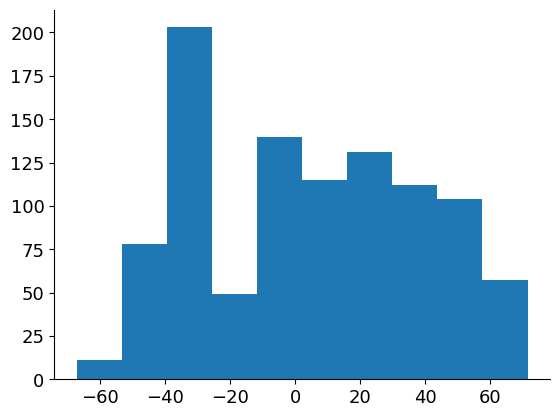

avg is 4.341867671947673


In [8]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode
reward_list = []
for _ in range(1000):
    env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
    episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
    reward_list.append(np.sum(episode['rewards']))

plt.hist(reward_list)
plt.show()
print(f'avg is {np.sum(reward_list)/len(reward_list)}')

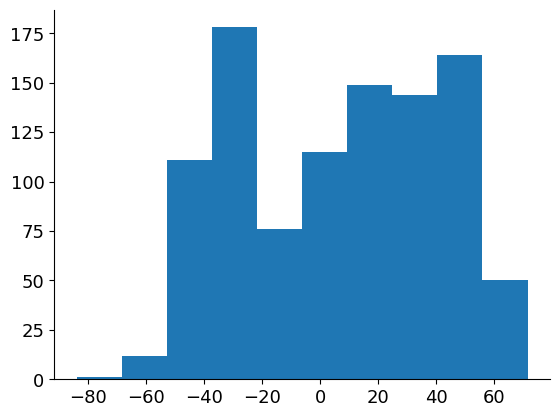

avg is 6.063064503971034


In [9]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode
reward_list = []
for _ in range(1000):
    env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
    episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
    reward_list.append(np.sum(episode['rewards']))

plt.hist(reward_list)
plt.show()
print(f'avg is {np.sum(reward_list)/len(reward_list)}')

In [17]:
from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode
avg_list = []
for _ in range(20):
    reward_list = []
    for no_eps in range(1000):
        env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
        episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
        reward_list.append(np.sum(episode['rewards']))
    avg_list.append(np.sum(reward_list)/len(reward_list))

# plt.hist(reward_list)
# plt.show()
# print(f'avg is {np.sum(reward_list)/len(reward_list)}')

In [19]:
avg_list

[2.57877873689955,
 3.8964404056462008,
 5.342714533174386,
 3.113453379327351,
 4.151653759445055,
 1.0774586811994729,
 5.226642347224029,
 5.739748826071782,
 5.179142690236348,
 4.192220217457054,
 4.632678044908352,
 5.014509979572467,
 2.194912008699729,
 4.329342412371429,
 5.8943311703380195,
 4.125000674148709,
 4.303116808173877,
 5.4266326140441645,
 3.8815208890077266,
 4.043406951550447]

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from auditoryforage.AF_env import AuditoryForaging
from auditoryforage.utils import plot_AF_episode

import torch

def find_activation(agent, belief):
    features = torch.tensor(belief, dtype=torch.float32)
    with torch.no_grad():
        policy_net_0_results = agent.algo.policy.mlp_extractor.policy_net[0](features)
        policy_net_1_results = agent.algo.policy.mlp_extractor.policy_net[1](policy_net_0_results)
        policy_net_2_results = agent.algo.policy.mlp_extractor.policy_net[2](policy_net_1_results)
        policy_net_3_results = agent.algo.policy.mlp_extractor.policy_net[3](policy_net_2_results)
        policy_net_4_results = agent.algo.policy.mlp_extractor.policy_net[4](policy_net_3_results)
    return policy_net_4_results

def get_att_lick_probs(episode):
    activations_list = []
    for belief in episode['beliefs'][:-1]: #Last belief is not used for action
        activations_list.append(find_activation(agent, belief).numpy())
    lick_feature = [activations_list[ind][0]  for ind in range(len(activations_list))]
    attention_feature = [activations_list[ind][1] for ind in range(len(activations_list))]
    lick_prob = [(1/(1+np.exp(-2 * elt))) for elt in lick_feature]
    attention_prob = [(1/(1+np.exp(-2 * elt))) for elt in attention_feature]
    return attention_prob, lick_prob

def pad_lists(list_of_lists):
    max_length = max(len(lst) for lst in list_of_lists)
    padded_lists = [lst + [0] * (max_length - len(lst)) for lst in list_of_lists]
    return padded_lists

def pad_zero_lick(data):
    num_rows = len(data)
    num_cols = max(data) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid

def pad_zero_attention(data):
    num_rows = len(data)
    num_cols = max(max(arr) for arr in data if len(arr) != 0) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid

def offset_to_first(data):
    offset_data = [[x - min(inner_list) for x in inner_list] for inner_list in data]
    return offset_data

def plot_over_episodes(data, title, plot_no_episodes = 100):
    
    if title == 'attention time':
        
        plt.figure()
        plt.plot(np.sum(pad_zero_attention(data), axis = 0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        plt.imshow(pad_zero_attention(plot_data), cmap='viridis', aspect='auto', interpolation='none')
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()

        plt.figure()
        plt.plot(np.sum(pad_zero_attention(offset_to_first(data)), axis = 0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title('offset' + title)
        plt.show()

        plot_data = offset_to_first(data[:plot_no_episodes])
        plt.figure()
        plt.imshow(pad_zero_attention(plot_data), cmap='viridis', aspect='auto', interpolation='none')
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title('offset ' + title)
        plt.show()

        # plt.figure()
        # tot_sum = np.sum(pad_zero_attention(offset_to_first(data)), axis = 0)/len(data)
        # plt.plot(tot_sum[2:])
        # plt.xlabel('time in trial')
        # plt.ylabel('normalized count')
        # plt.title('offset and removed first ' + title)
        # plt.show()
    
    elif title == 'lick time':

        plt.figure()
        plt.plot(np.sum(pad_zero_lick(data), axis = 0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        plt.imshow(pad_zero_lick(plot_data), cmap='viridis', aspect='auto', interpolation='none')
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()

    else:
    
        plt.figure()
        plt.plot(np.sum(pad_lists(data), axis = 0)/len(data))
        plt.xlabel('time in trial')
        plt.ylabel('normalized count')
        plt.title(title)
        plt.show()

        plot_data = data[:plot_no_episodes]
        plt.figure()
        plt.imshow(pad_lists(plot_data), cmap='viridis', aspect='auto', interpolation='none')
        plt.xlabel('time in trial')
        plt.ylabel('episode no.')
        plt.title(title)
        plt.show()


env_param = [0, 800, 0.087213, .25, -30, 0, 0]
env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 10
agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = 3)

attention_prob_list = []
lick_prob_list = []
lick_time_list = []
att_time_list = []

num_episodes = 1500

for ep_no in range(num_episodes):
    episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
    att_time_list.append(np.where(np.array([elt[1] for elt in episode['actions']] )== 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)

    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    
    

plot_over_episodes(attention_prob_list, title = 'attention prob.', plot_no_episodes = 100)
plot_over_episodes(lick_prob_list, title = 'lick prob.', plot_no_episodes = 100)
plot_over_episodes(lick_time_list, title = 'lick time', plot_no_episodes = 100)
plot_over_episodes(att_time_list, title = 'attention time', plot_no_episodes = 100)

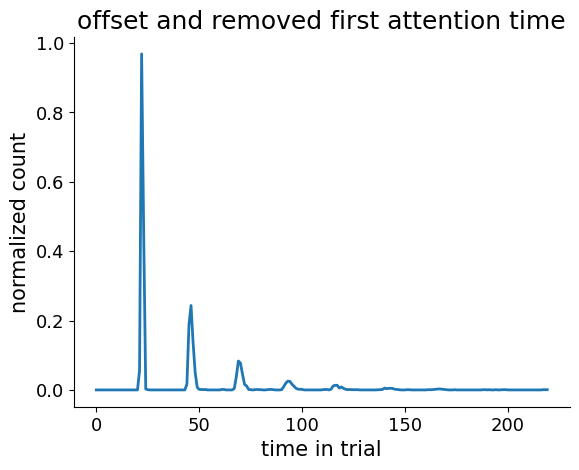

In [44]:

data = att_time_list 
title = 'attention time'
plot_no_episodes = 100

plt.figure()
tot_sum = np.sum(pad_zero_attention(data), axis = 0)/len(data)
plt.plot(tot_sum[1:])
plt.xlabel('time in trial')
plt.ylabel('normalized count')
plt.title('offset and removed first ' + title)
plt.show()

working on 800
Checkpoint (epoch 720) loaded.
working on 900
Checkpoint (epoch 721) loaded.
working on 1000
Checkpoint (epoch 715) loaded.
working on 1100
Checkpoint (epoch 715) loaded.
working on 1300
Checkpoint (epoch 715) loaded.
working on 1400
Checkpoint (epoch 715) loaded.
working on 1500
Checkpoint (epoch 717) loaded.


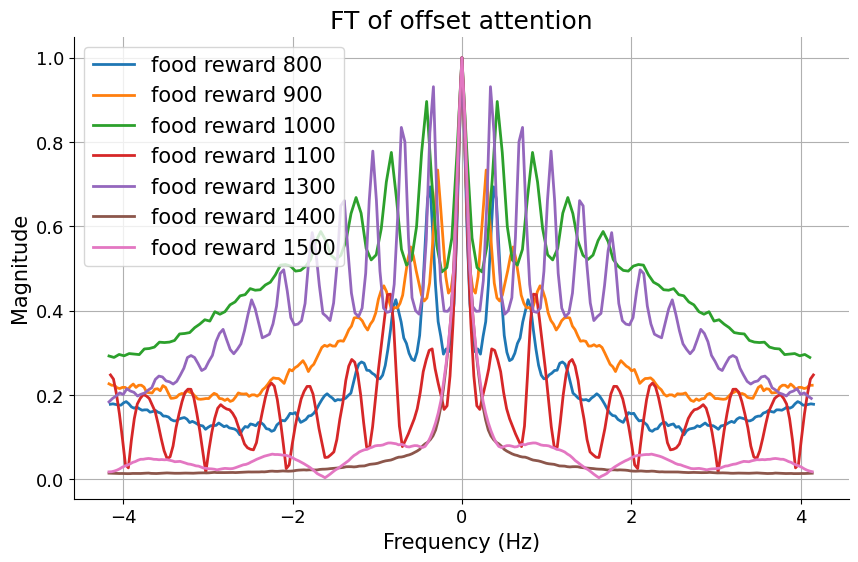

In [34]:
# fr_list = [800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
fr_list = [800, 900, 1000, 1100, 1300, 1400, 1500]
do_offset = True
plot_together = True
do_normalize = True

if plot_together:
    plt.figure(figsize=(10, 6))
    
for fr_val in fr_list:

    env_param = [0, fr_val, 0.087213, .25, -30, 0, 0]
    env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
    num_epochs = 10
    agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = 3)

    attention_prob_list = []
    lick_prob_list = []
    lick_time_list = []
    att_time_list = []

    num_episodes = 1000

    for ep_no in range(num_episodes):
        episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
        att_time_list.append(np.where(np.array([elt[1] for elt in episode['actions']] )== 1)[0])
        attention_prob, lick_prob = get_att_lick_probs(episode)
        attention_prob_list.append(attention_prob)
        lick_prob_list.append(lick_prob)

        if episode['actions'][-1][0] == 1:
            lick_time_list.append(len(episode['states']))

    
    data = att_time_list 
    title = 'attention time'
    sampl_freq = 25/3

    if do_offset:
        tot_sum = np.sum(pad_zero_attention(offset_to_first(data)), axis = 0)/len(data)
    else:
        tot_sum = np.sum(pad_zero_attention(data), axis = 0)/len(data)

    if do_normalize:
        tot_sum /= np.sum(tot_sum)

    fourier_transform = np.fft.fft(tot_sum)
    frequencies = np.fft.fftfreq(len(tot_sum), 1/sampl_freq)  # Compute frequencies
    order = np.argsort(frequencies)

    
    if plot_together:
        plt.plot(frequencies[order], np.abs(fourier_transform)[order], label = 'food reward ' + str(fr_val))  # Plot magnitude of Fourier Transform
    else:
        plt.figure()
        plt.plot(frequencies[order], np.abs(fourier_transform)[order], label = 'food reward ' + str(fr_val))  # Plot magnitude of Fourier Transform
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        if do_offset:
            plt.title('FT of offset attention')
        else:
            plt.title('FT of attention')
        plt.legend()
        plt.grid(True)
        plt.show()

if plot_together:
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    if do_offset:
        plt.title('FT of offset attention')
    else:
        plt.title('FT of attention')
    plt.legend()
    plt.grid(True)
    plt.show()

In [38]:
fr_list = [800, 900, 1000, 1100, 1300, 1400, 1500]

ft_data = {}

for fr_val in fr_list:

    ft_data[fr_val] = {}

    env_param = [0, fr_val, 0.087213, .25, -30, 0, 0]
    env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
    num_epochs = 10
    agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = 3)

    attention_prob_list = []
    lick_prob_list = []
    lick_time_list = []
    att_time_list = []

    num_episodes = 1000

    for ep_no in range(num_episodes):
        episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
        att_time_list.append(np.where(np.array([elt[1] for elt in episode['actions']] )== 1)[0])
        attention_prob, lick_prob = get_att_lick_probs(episode)
        attention_prob_list.append(attention_prob)
        lick_prob_list.append(lick_prob)

        if episode['actions'][-1][0] == 1:
            lick_time_list.append(len(episode['states']))

    
    data = att_time_list 
    title = 'attention time'
    sampl_freq = 25/3

    
    no_normalized_offset_tot_sum = np.sum(pad_zero_attention(offset_to_first(data)), axis = 0)/len(data)
    no_normalized_no_offset_tot_sum = np.sum(pad_zero_attention(data), axis = 0)/len(data)
    normalized_offset_tot_sum = no_normalized_offset_tot_sum/np.sum(no_normalized_offset_tot_sum)
    normalized_no_offset_tot_sum = no_normalized_no_offset_tot_sum/np.sum(no_normalized_no_offset_tot_sum)

    no_normalized_offset_ft = np.fft.fft(no_normalized_offset_tot_sum)
    no_normalized_no_offset_ft = np.fft.fft(no_normalized_no_offset_tot_sum)
    normalized_offset_ft = np.fft.fft(normalized_offset_tot_sum)
    normalized_no_offset_ft = np.fft.fft(normalized_no_offset_tot_sum)
    
    no_normalized_offset_freqs = np.fft.fftfreq(len(no_normalized_offset_tot_sum), 1/sampl_freq)
    no_normalized_no_offset_freqs = np.fft.fftfreq(len(no_normalized_no_offset_tot_sum), 1/sampl_freq)
    normalized_offset_freqs = np.fft.fftfreq(len(normalized_offset_tot_sum), 1/sampl_freq)
    normalized_no_offset_freqs = np.fft.fftfreq(len(normalized_no_offset_tot_sum), 1/sampl_freq)
    
    no_normalized_offset_order = np.argsort(no_normalized_offset_freqs)
    no_normalized_no_offset_order = np.argsort(no_normalized_no_offset_freqs)
    normalized_offset_order = np.argsort(normalized_offset_freqs)
    normalized_no_offset_order = np.argsort(normalized_no_offset_freqs)

    ft_data[fr_val]['no_normalized_offset'] = {}
    ft_data[fr_val]['no_normalized_offset']['freq'] = no_normalized_offset_freqs[no_normalized_offset_order]
    ft_data[fr_val]['no_normalized_offset']['mag'] = np.abs(no_normalized_offset_ft)[no_normalized_offset_order]

    ft_data[fr_val]['no_normalized_no_offset'] = {}
    ft_data[fr_val]['no_normalized_no_offset']['freq'] = no_normalized_no_offset_freqs[no_normalized_no_offset_order]
    ft_data[fr_val]['no_normalized_no_offset']['mag'] = np.abs(no_normalized_no_offset_ft)[no_normalized_no_offset_order]

    ft_data[fr_val]['normalized_offset'] = {}
    ft_data[fr_val]['normalized_offset']['freq'] = normalized_offset_freqs[normalized_offset_order]
    ft_data[fr_val]['normalized_offset']['mag'] = np.abs(normalized_offset_ft)[normalized_offset_order]

    ft_data[fr_val]['normalized_no_offset'] = {}
    ft_data[fr_val]['normalized_no_offset']['freq'] = normalized_no_offset_freqs[normalized_no_offset_order]
    ft_data[fr_val]['normalized_no_offset']['mag'] = np.abs(normalized_no_offset_ft)[normalized_no_offset_order]

from auditoryforage.utils import save_pickle_file
file_name = './store/ft_data.pkl'
save_pickle_file(ft_data, file_name)

Checkpoint (epoch 720) loaded.
Checkpoint (epoch 721) loaded.
Checkpoint (epoch 715) loaded.
Checkpoint (epoch 715) loaded.
Checkpoint (epoch 715) loaded.
Checkpoint (epoch 715) loaded.
Checkpoint (epoch 717) loaded.
